# **SwipeWise — Predicting the Fate of a Match**

**Group members:**

Full ML pipeline: EDA → Preprocessing → Feature Engineering & Selection → Modeling → Evaluation

---
# Part 1 — Exploratory Data Analysis

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sbn

#loading both datasets into Colab
df_base = pd.read_csv("dating_app_behavior_dataset.csv")
df_extended = pd.read_csv("dating_app_behavior_dataset_extended1.csv")

#printing out their shapes (Rows, Columns)
print(f"Base Dataset Dimensions: {df_base.shape}")
print(f"Extended Dataset Dimensions: {df_extended.shape}")

Base Dataset Dimensions: (50000, 19)
Extended Dataset Dimensions: (50000, 25)


In [ ]:
#check if there are any brand-new columns in the extended version
new_cols = set(df_extended.columns) - set(df_base.columns)
print(f"New columns found in the Extended file: {list(new_cols) if new_cols else 'None (They share identical columns)'}")

#calculate the difference in data volume
row_diff = df_extended.shape[0] - df_base.shape[0]
print(f"The Extended file provides {row_diff} additional rows of user interactions!")

New columns found in the Extended file: ['zodiac_sign', 'body_type', 'height_cm', 'weight_kg', 'relationship_intent', 'age']
The Extended file provides 0 additional rows of user interactions!


Since the extended one has more columns a.k.a data, going forth we will be using the extended dataset / csv file

In [ ]:
# setting the sxtended dataset as our primary dataset
df = df_extended

In [ ]:
#1.check for missing/null values that need cleaning later on
print("___Missing Rows Per Variable___")
print(df.isnull().sum())

#2. inspecting data types (Categorical objects vs Numerical floats/ints)
print("\n___Feature Data Types___")
print(df.dtypes)

#3. displaying summary statistics (Mean, Median, Min, Max)
df.describe()

___Missing Rows Per Variable___
gender                  0
sexual_orientation      0
location_type           0
income_bracket          0
education_level         0
interest_tags           0
app_usage_time_min      0
app_usage_time_label    0
swipe_right_ratio       0
swipe_right_label       0
likes_received          0
mutual_matches          0
profile_pics_count      0
bio_length              0
message_sent_count      0
emoji_usage_rate        0
last_active_hour        0
swipe_time_of_day       0
match_outcome           0
age                     0
height_cm               0
weight_kg               0
zodiac_sign             0
body_type               0
relationship_intent     0
dtype: int64

___Feature Data Types___
gender                   object
sexual_orientation       object
location_type            object
income_bracket           object
education_level          object
interest_tags            object
app_usage_time_min        int64
app_usage_time_label     object
swipe_right_ratio      

,app_usage_time_min,swipe_right_ratio,likes_received,mutual_matches,profile_pics_count,bio_length,message_sent_count,emoji_usage_rate,last_active_hour,age,height_cm,weight_kg
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,149.912400,0.500655,99.526040,13.870280,2.98772,250.174400,50.07194,0.286205,11.521800,38.477920,172.584260,72.099052
std,86.990521,0.197468,57.996799,9.105615,1.99678,144.800996,29.16800,0.160042,6.920474,12.128435,16.134926,17.071441
min,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,0.000000,18.000000,145.000000,37.800000
25%,74.000000,0.370000,49.000000,6.000000,1.00000,125.000000,25.00000,0.160000,5.000000,28.000000,159.000000,59.200000
50%,150.000000,0.500000,100.000000,13.000000,3.00000,250.000000,50.00000,0.270000,12.000000,38.000000,173.000000,70.300000
75%,225.000000,0.640000,150.000000,22.000000,5.00000,376.000000,75.00000,0.390000,18.000000,49.000000,187.000000,83.800000
max,300.000000,1.000000,200.000000,30.000000,6.00000,500.000000,100.00000,0.940000,23.000000,59.000000,200.000000,120.000000


In [ ]:
#checking exact text categories; how many rows belong to each outcome
print(df['match_outcome'].value_counts())

match_outcome
One-sided Like         5112
Instant Match          5078
Blocked                5049
Catfished              5025
Chat Ignored           5019
Mutual Match           4990
No Action              4986
Ghosted                4959
Date Happened          4919
Relationship Formed    4863
Name: count, dtype: int64


Going forward we are gonna be using "match_outcome" as our target variable

/tmp/ipykernel_11219/1369262362.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sbn.countplot(data=df, x='match_outcome', order=df['match_outcome'].value_counts().index, palette='viridis')


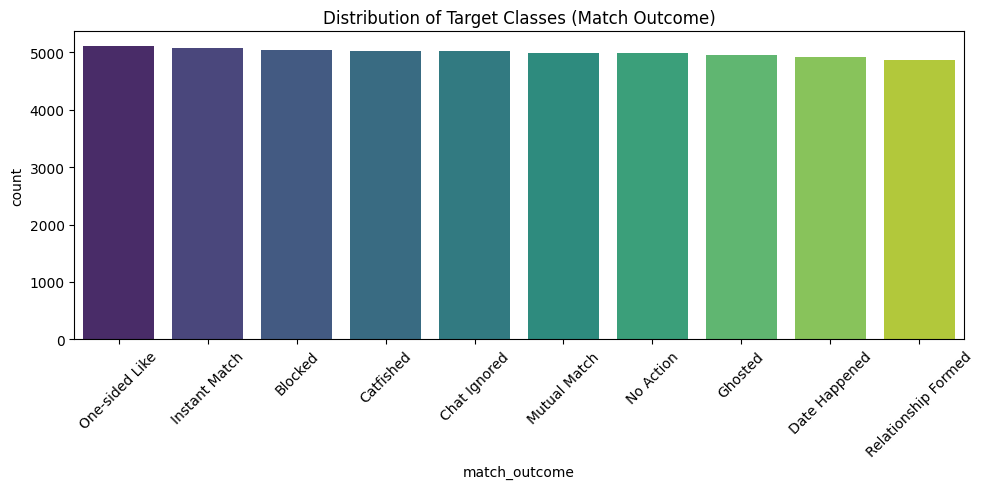

In [ ]:
plt.figure(figsize=(10, 5))

#pllotting the target columns category distribution
sbn.countplot(data=df, x='match_outcome', order=df['match_outcome'].value_counts().index, palette='viridis')

plt.title('Distribution of Target Classes (Match Outcome)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

How pictures effect match outcomes:

/tmp/ipykernel_11219/3678207046.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sbn.boxplot(data=df, x='match_outcome', y='profile_pics_count', palette='Set2')


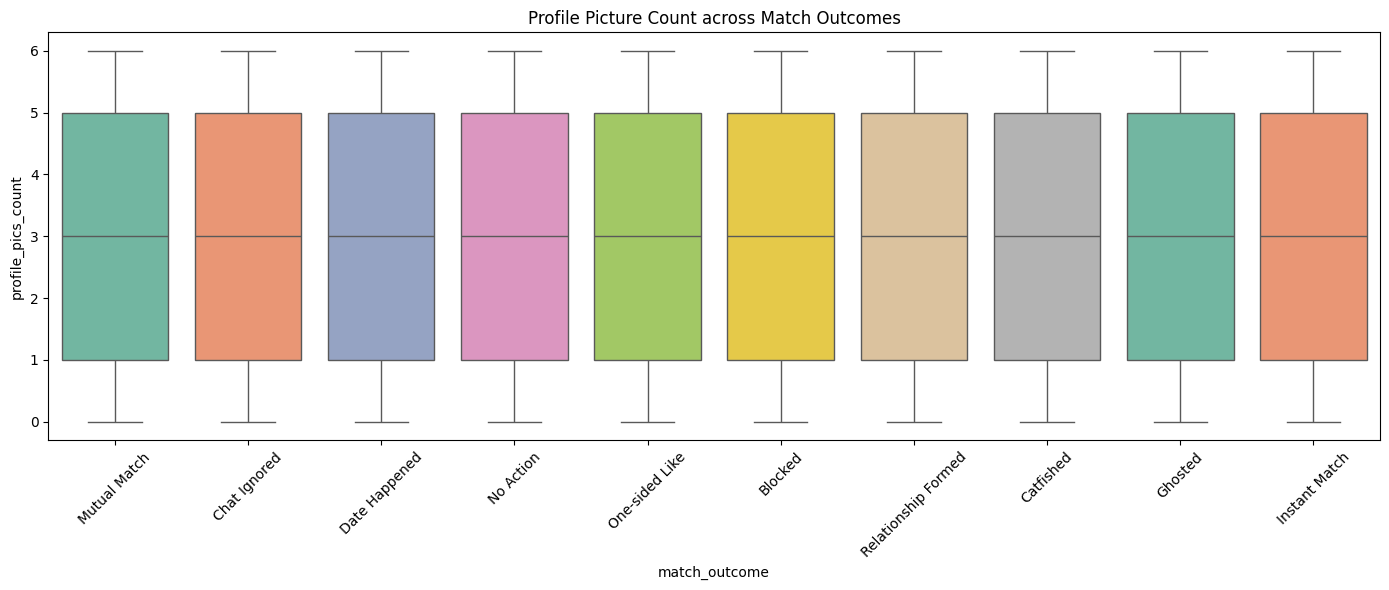

In [ ]:
plt.figure(figsize=(14, 6))
sbn.boxplot(data=df, x='match_outcome', y='profile_pics_count', palette='Set2')
plt.title('Profile Picture Count across Match Outcomes')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

So, as from the above we can see that pictures have totally 0 correlation with matches in this particular dataset. Meaning that we can remove it later on.

Now, calculating mean from behaivours for more insight

In [ ]:
# Let's see the average behavior metrics for each specific match outcome group
analysis_summary = df.groupby('match_outcome')[['swipe_right_ratio', 'app_usage_time_min', 'message_sent_count', 'likes_received']].mean()
analysis_summary

,swipe_right_ratio,app_usage_time_min,message_sent_count,likes_received
match_outcome,,,,
Blocked,0.502678,150.962963,49.678352,98.451178
Catfished,0.503686,150.280796,50.074030,100.078010
Chat Ignored,0.502865,149.130703,49.812712,100.598526
Date Happened,0.496595,150.203700,50.655824,99.219760
Ghosted,0.501797,149.942529,50.120387,99.318814
Instant Match,0.503316,149.834384,50.609886,98.599842
Mutual Match,0.493898,151.555311,50.446293,100.337876
No Action,0.499613,150.143000,49.795628,99.331328
One-sided Like,0.498619,148.086268,49.867371,99.268192


after calculating the average behavior metrics (like messages sent and app usage time) for each of the 10 match outcomes we see that the numbers are almost identical across the board; For example, users send about 50 messages regardless of whether they get blocked or form a relationship which proves that these individual numeric features are completely randomized and have **ZERO correlation** with the final result. The preprocessing team should focus on combining features or unpacking text columns like interest_tags, because relying on these raw numbers alone will leave the AI model blindly guessing.

**Final EDA Summary**

-Selected Target: match_outcome (with 10 categories).

-Data Distribution: the target classes are perfectly balanced (roughly 5,000 rows each across 50,000 total rows), so we should be able to just use use standard accuracy metrics without worrying about class imbalances.

-Data Cleaning: we should delete the columns "app_usage_time_label" and "swipe_right_label" right away because they are just word-versions of the number columns we already have. Also, gotta be careful with "mutual_matches" so the AI doesn't accidently "cheat" during training.

-What to Do Next: Since the basic numbers (like swipe rates) are totally random, the next step needs to focus on converting text categories (like zodiac_sign or relationship_intent) into numbers and breaking down the interest_tags column so the AI can actually find real patterns.

---
# Part 2 — Data Preprocessing
Clean the data, turn everything into numbers, and make one shared train/test split.

**Key rule:** anything that learns from data (scaler) is fit on the **training set only** so no test information leaks in.

### Step 1 — Load data and drop columns we don't need
- `app_usage_time_label` and `swipe_right_label` are word versions of numbers we already have.
- `mutual_matches` is dropped to avoid leakage (it can give away the match outcome).

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

df = pd.read_csv('dating_app_behavior_dataset_extended1.csv')
df = df.drop(columns=['app_usage_time_label', 'swipe_right_label', 'mutual_matches'])
print('Shape after dropping:', df.shape)

### Step 2 — Split `interest_tags` into separate yes/no columns
Each user has 3 comma-separated interests in one cell. `str.get_dummies` turns every interest into its own 0/1 column.

In [ ]:
interests = df['interest_tags'].str.get_dummies(sep=', ').add_prefix('interest_')
df = pd.concat([df.drop(columns=['interest_tags']), interests], axis=1)
print('Interest columns created:', interests.shape[1])

### Step 3 — Ordinal encode the ranked columns
`income_bracket` and `education_level` have a natural order, so we map them to ranked numbers (0 = lowest). We first replace the curly apostrophe (’) so the mapping matches.

In [ ]:
income_order = ['Very Low', 'Low', 'Lower-Middle', 'Middle', 'Upper-Middle', 'High', 'Very High']
education_order = ['No Formal Education', 'High School', 'Diploma', "Associate's",
                   "Bachelor's", 'MBA', "Master's", 'PhD', 'Postdoc']

df['education_level'] = df['education_level'].str.replace('\u2019', "'")
df['income_bracket'] = df['income_bracket'].map({c: i for i, c in enumerate(income_order)})
df['education_level'] = df['education_level'].map({c: i for i, c in enumerate(education_order)})
print('Any unmapped values?', df[['income_bracket', 'education_level']].isna().sum().sum())

### Step 4 — One-hot encode the remaining text columns
The leftover text columns (gender, location, zodiac, etc.) have no order, so each category becomes its own 0/1 column. We exclude the target.

In [ ]:
text_cols = [c for c in df.select_dtypes('object').columns if c != 'match_outcome']
df = pd.get_dummies(df, columns=text_cols)

# get_dummies makes True/False columns - convert them to 1/0 so models read them as numbers
bool_cols = df.select_dtypes('bool').columns
df[bool_cols] = df[bool_cols].astype(int)
print('Shape after encoding:', df.shape)

### Step 5 — Encode the target and split into train/test
Turn the 10 outcome names into numbers 0–9, then split 80/20 (stratified, so all 10 classes stay balanced). Scaling is done in Part 3, **after** we finish creating features.

In [ ]:
target_encoder = LabelEncoder()
X = df.drop(columns=['match_outcome'])
y = target_encoder.fit_transform(df['match_outcome'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
print('Train:', X_train.shape, '| Test:', X_test.shape)

---
# Part 3 — Feature Engineering & Selection
Build a couple of meaningful new features, scale the numbers, then check which features actually matter.

### Step 6 — Create two new features
We combine existing columns into features with clearer meaning:
- **`bmi`** = weight ÷ height² (body profile in one number)
- **`engagement_ratio`** = likes received per message sent (attention vs effort)

These are worked out row-by-row, so doing them on train and test separately is safe (no leakage).

In [ ]:
for data in (X_train, X_test):
    data['bmi'] = data['weight_kg'] / (data['height_cm'] / 100) ** 2
    data['engagement_ratio'] = data['likes_received'] / (data['message_sent_count'] + 1)
print('Features now:', X_train.shape[1])

### Step 7 — Scale the numeric features
A column with only two values is just a 0/1 flag; a column with more values is a real measurement, so we scale those. The scaler is **fit on the training set only**, then applied to test.

In [ ]:
numeric = [c for c in X_train.columns if X_train[c].nunique() > 2]

scaler = StandardScaler()
X_train[numeric] = scaler.fit_transform(X_train[numeric])
X_test[numeric] = scaler.transform(X_test[numeric])
print('Scaled', len(numeric), 'columns')

### Step 8 — Which features matter? (Random Forest importance)
A quick Random Forest gives an importance score for each feature — how useful it is for predicting the outcome. We plot the top 15.

In [ ]:
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1).fit(X_train, y_train)
importance = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values()
importance.tail(15).plot.barh(figsize=(7, 6), title='Top 15 features by importance')
plt.tight_layout(); plt.show()

### Step 9 — PCA check
PCA tells us how many components are needed to keep 95% of the information. If we still need a lot of components, the features are mostly independent (little redundancy to remove).

In [ ]:
from sklearn.decomposition import PCA

cum = PCA().fit(X_train).explained_variance_ratio_.cumsum()
print(int((cum < 0.95).sum() + 1), 'components keep 95% of the variance, out of', X_train.shape[1])

### Step 10 — Decision and save
The importance scores are almost equal and PCA shows little redundancy — both match the EDA finding that the features carry very little signal. So we **keep all features** (dropping any would just throw away information on weak evidence) and save the final data for the modeling team.

In [ ]:
import joblib

X_train.to_csv('X_train.csv', index=False)
X_test.to_csv('X_test.csv', index=False)
pd.Series(y_train, name='match_outcome').to_csv('y_train.csv', index=False)
pd.Series(y_test, name='match_outcome').to_csv('y_test.csv', index=False)
joblib.dump(scaler, 'scaler.joblib')
joblib.dump(target_encoder, 'target_encoder.joblib')
print('Saved. Final feature count:', X_train.shape[1])